# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [30]:
# If on colab, uncomment the following lines

# ! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [32]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,491,97,45,76,175,60,9,157,42,20,149,180,370,169,63,16,12,198,206
1,764,103,53,106,172,55,10,212,32,24,168,220,660,223,73,16,24,187,197
2,804,104,52,101,206,62,10,198,33,23,161,207,587,204,64,2,5,195,204
3,739,96,44,85,166,66,10,155,43,19,150,167,355,159,67,3,10,192,202
4,104,102,45,83,198,65,5,194,33,22,146,225,576,167,79,0,27,193,191
5,146,100,46,85,164,64,11,163,42,20,163,176,387,170,71,18,0,189,196
6,332,99,57,109,220,66,11,221,30,25,176,234,725,236,70,10,25,188,200
7,196,107,56,104,231,71,11,219,31,25,172,226,705,217,71,19,11,189,196
8,204,89,40,58,137,58,7,122,54,17,140,146,225,150,63,7,4,199,206
9,522,89,36,69,162,63,6,140,48,18,131,164,291,126,66,1,38,193,204


Methods `describe` and `info` deliver some useful information.

In [33]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,422.296903,93.936248,45.025501,82.595628,170.298725,61.979964,8.770492,169.683060,40.721311,20.644809,148.353370,189.622951,444.009107,175.761384,72.522769,6.526412,12.475410,188.990893,195.770492
std,247.952803,8.269278,6.204784,15.805514,34.391027,8.901199,5.408003,33.165666,7.789938,2.595525,14.629079,31.518878,176.001021,32.893428,7.949770,5.227815,9.112328,6.175203,7.428624
min,0.000000,76.000000,33.000000,49.000000,104.000000,47.000000,3.000000,114.000000,26.000000,17.000000,118.000000,132.000000,192.000000,109.000000,60.000000,0.000000,0.000000,176.000000,181.000000
25%,202.000000,88.000000,40.000000,70.000000,142.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,168.000000,320.000000,150.000000,67.000000,2.000000,5.000000,185.000000,191.000000
50%,417.000000,93.000000,45.000000,80.000000,169.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,180.000000,367.000000,174.000000,72.000000,5.000000,11.000000,188.000000,197.000000
75%,646.000000,100.000000,50.000000,98.000000,197.000000,66.000000,10.000000,201.000000,46.000000,23.000000,160.000000,218.000000,602.000000,200.000000,75.000000,10.000000,19.000000,193.000000,201.000000
max,845.000000,119.000000,58.000000,112.000000,333.000000,138.000000,55.000000,261.000000,59.000000,28.000000,188.000000,320.000000,998.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [34]:
X_train_pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

base_model = LogisticRegression(solver='saga', tol=1e-3, max_iter=500)
base_model.fit(X_train_scaled, y_train)

y_pred = base_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Точность base модели: {accuracy:.4f}')


model = LogisticRegression(solver='saga', tol=1e-3, max_iter=500)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(model, param_grid, scoring='accuracy', cv=5)
grid.fit(X_train_scaled, y_train)

print("best params C = ", grid.best_params_)
print("best score = ", grid.best_score_)
print("best estimator = ", grid.best_estimator_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Точность best модели: {accuracy:.4f}')
print(f"Weighted F1: {f1:.4f}")

Точность base модели: 0.7845
best params C =  {'C': 100}
best score =  0.7869557964970809
best estimator =  LogisticRegression(C=100, max_iter=500, solver='saga', tol=0.001)
Точность best модели: 0.8047
Weighted F1: 0.8047


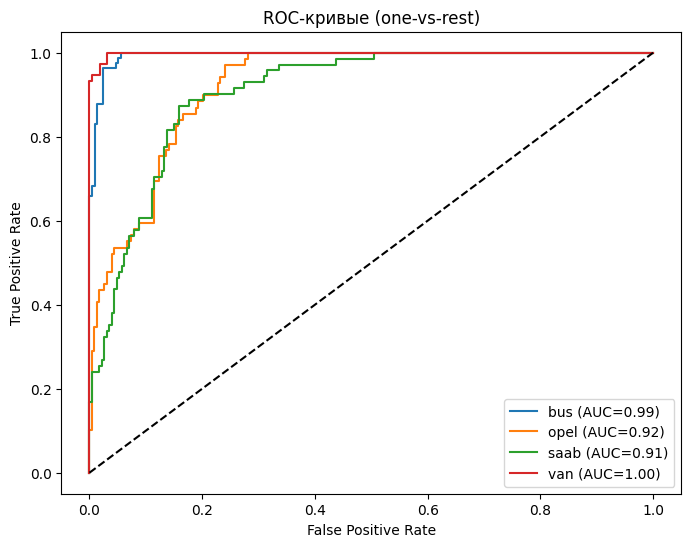

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Бинаризуем метки (преобразуем строки в one-hot)
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)  # матрица (297, 4)

plt.figure(figsize=(8,6))

for i, class_name in enumerate(best_model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые (one-vs-rest)')
plt.legend()
plt.show()

In [38]:
# You might use this command to install scikit-plot. 
# Warning, if you a running locally, don't   pip from within jupyter, call it from terminal in the corresponding 
# virtual environment instead

# ! pip install scikit-plot

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot. у

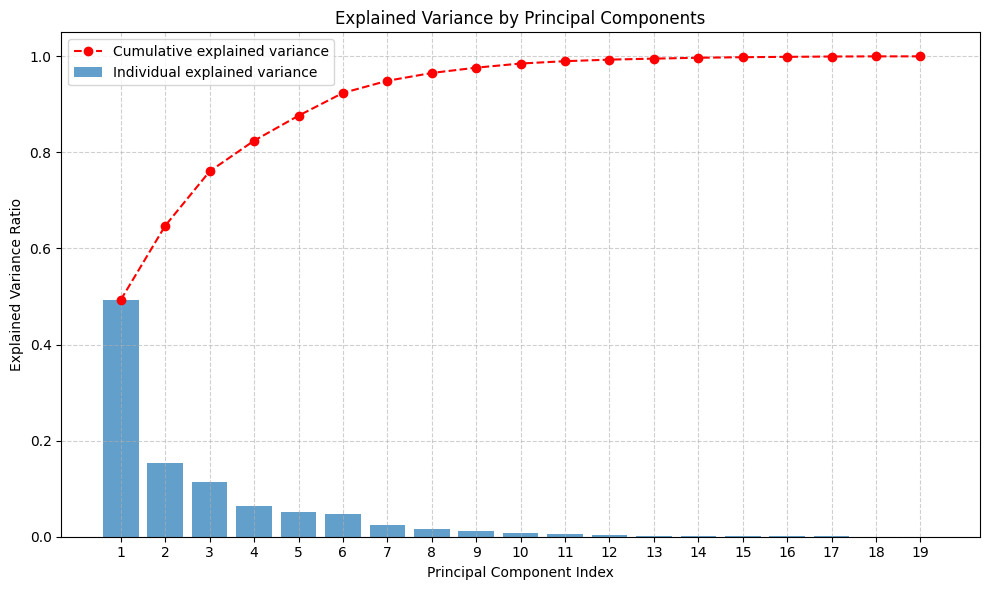

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=None)
pca.fit(X_train_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))

plt.bar(range(1, len(explained_variance_ratio) + 1), 
        explained_variance_ratio, 
        alpha=0.7, 
        label='Individual explained variance')

plt.plot(range(1, len(explained_variance_ratio) + 1), 
         np.cumsum(explained_variance_ratio), 
         marker='o', 
         linestyle='--', 
         color='r', 
         label='Cumulative explained variance')

plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.tight_layout() 

plt.show()

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

I choose 11 components because the explained variance ratios for components 12 and higher are very close to zero

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition import PCA

k = 11

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=k))
])

pca_pipeline.fit(X_train)

X_train_pca = pca_pipeline.transform(X_train)
X_test_pca  = pca_pipeline.transform(X_test )

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

Accuracy: 0.7306, Weighted F1: 0.7281


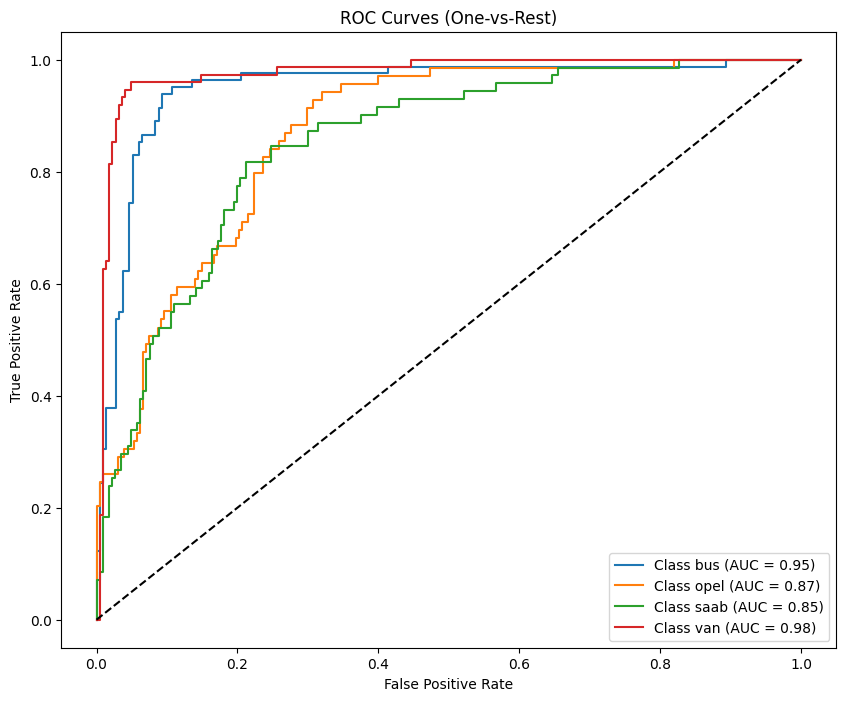

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

model = LogisticRegression(solver='saga', tol=1e-3, max_iter=1000)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_pca, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_pca)
y_proba = best_model.predict_proba(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}, Weighted F1: {f1:.4f}')

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=best_model.classes_)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {best_model.classes_[i]} (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.show()

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble? 

In [ ]:
# YOUR CODE HERE

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it? 

In [ ]:
# YOUR CODE HERE